In [1]:
import pandas as pd
import glob
import os
import re

BASE_DIR = "Week08/raw_csv/type1_time_stress"
OUTPUT_FILE = "Week08/results/perovai_type1_timeseries_week08.csv"

HTL = "MeO2PACz"
ELECTRODE = "Ag"
TYPE = "Type1"
WEEK = 8


In [2]:
def parse_filename(fname):
    name = os.path.basename(fname).replace(".csv", "")
    
    stress_mode = "stepstress" if "stepstress" in name else "constant"
    
    # voltage
    m_v = re.search(r"_(\d+p\d+)V", name)
    stress_voltage = float(m_v.group(1).replace("p", ".")) if m_v else None
    
    # duration
    if "stepstress" in name:
        stress_duration = 60  # seconds
    else:
        m_t = re.search(r"_(\d+)h_", name)
        stress_duration = int(m_t.group(1)) * 3600 if m_t else None
    
    return stress_mode, stress_voltage, stress_duration

In [5]:
import os
print("Current working directory:")
print(os.getcwd())

Current working directory:
c:\Users\Mazhar\Desktop\PerovAI_Course\Week08\notebooks


In [6]:
BASE_DIR = "../raw_csv/type1_time_stress"

In [7]:
import glob, os

print("BASE_DIR =", BASE_DIR)
print("Exists:", os.path.exists(BASE_DIR))
print("CSV files found:")
print(glob.glob(os.path.join(BASE_DIR, "*.csv")))

BASE_DIR = ../raw_csv/type1_time_stress
Exists: True
CSV files found:
['../raw_csv/type1_time_stress\\MeO2PACz_Ag_15h_0p8V.csv', '../raw_csv/type1_time_stress\\MeO2PACz_Ag_15h_1p5V.csv', '../raw_csv/type1_time_stress\\MeO2PACz_Ag_1h_0p8V.csv', '../raw_csv/type1_time_stress\\MeO2PACz_Ag_stepstress_0p2V.csv', '../raw_csv/type1_time_stress\\MeO2PACz_Ag_stepstress_0p4V.csv', '../raw_csv/type1_time_stress\\MeO2PACz_Ag_stepstress_0p6V.csv', '../raw_csv/type1_time_stress\\MeO2PACz_Ag_stepstress_0p8V.csv', '../raw_csv/type1_time_stress\\MeO2PACz_Ag_stepstress_1p5V.csv', '../raw_csv/type1_time_stress\\MeO2PACz_Ag_stepstress_1V.csv']


In [8]:
rows = []

files = glob.glob(os.path.join(BASE_DIR, "*.csv"))
print("Found files:", files)

for f in files:
    stress_mode, stress_voltage, stress_duration = parse_filename(f)
    df = pd.read_csv(f)
    df.columns = ["MeasuredVoltage", "MeasuredCurrent"]
    
    df["StressMode"] = stress_mode
    df["StressVoltage"] = stress_voltage
    df["StressDuration_s"] = stress_duration
    df["HTL"] = HTL
    df["Electrode"] = ELECTRODE
    df["Type"] = TYPE
    df["Week"] = WEEK
    df["SourceFile"] = os.path.basename(f)
    
    rows.append(df)

if len(rows) == 0:
    raise RuntimeError("No CSV files loaded — check BASE_DIR")

type1_df = pd.concat(rows, ignore_index=True)
type1_df.head()

Found files: ['../raw_csv/type1_time_stress\\MeO2PACz_Ag_15h_0p8V.csv', '../raw_csv/type1_time_stress\\MeO2PACz_Ag_15h_1p5V.csv', '../raw_csv/type1_time_stress\\MeO2PACz_Ag_1h_0p8V.csv', '../raw_csv/type1_time_stress\\MeO2PACz_Ag_stepstress_0p2V.csv', '../raw_csv/type1_time_stress\\MeO2PACz_Ag_stepstress_0p4V.csv', '../raw_csv/type1_time_stress\\MeO2PACz_Ag_stepstress_0p6V.csv', '../raw_csv/type1_time_stress\\MeO2PACz_Ag_stepstress_0p8V.csv', '../raw_csv/type1_time_stress\\MeO2PACz_Ag_stepstress_1p5V.csv', '../raw_csv/type1_time_stress\\MeO2PACz_Ag_stepstress_1V.csv']


C:\Users\Mazhar\AppData\Local\Temp\ipykernel_23236\1283053291.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  type1_df = pd.concat(rows, ignore_index=True)


,MeasuredVoltage,MeasuredCurrent,StressMode,StressVoltage,StressDuration_s,HTL,Electrode,Type,Week,SourceFile
0,1.20,-29.977912,constant,0.8,54000,MeO2PACz,Ag,Type1,8,MeO2PACz_Ag_15h_0p8V.csv
1,1.18,-29.977220,constant,0.8,54000,MeO2PACz,Ag,Type1,8,MeO2PACz_Ag_15h_0p8V.csv
2,1.16,-25.316807,constant,0.8,54000,MeO2PACz,Ag,Type1,8,MeO2PACz_Ag_15h_0p8V.csv
3,1.14,-13.363572,constant,0.8,54000,MeO2PACz,Ag,Type1,8,MeO2PACz_Ag_15h_0p8V.csv
4,1.12,-4.027651,constant,0.8,54000,MeO2PACz,Ag,Type1,8,MeO2PACz_Ag_15h_0p8V.csv


In [9]:
print("Total rows:", len(type1_df))
print("Columns:", list(type1_df.columns))
print("\nStress modes:")
print(type1_df["StressMode"].value_counts())
print("\nStress voltages:")
print(type1_df["StressVoltage"].value_counts().sort_index())
print("\nStress durations (s):")
print(type1_df["StressDuration_s"].value_counts())

Total rows: 639
Columns: ['MeasuredVoltage', 'MeasuredCurrent', 'StressMode', 'StressVoltage', 'StressDuration_s', 'HTL', 'Electrode', 'Type', 'Week', 'SourceFile']

Stress modes:
StressMode
stepstress    426
constant      213
Name: count, dtype: int64

Stress voltages:
StressVoltage
0.2     71
0.4     71
0.6     71
0.8    213
1.5    142
Name: count, dtype: int64

Stress durations (s):
StressDuration_s
60       426
54000    142
3600      71
Name: count, dtype: int64


In [10]:
type1_df = type1_df.sort_values(
    by=["StressMode", "StressVoltage", "StressDuration_s", "MeasuredVoltage"]
).reset_index(drop=True)

type1_df.head()

,MeasuredVoltage,MeasuredCurrent,StressMode,StressVoltage,StressDuration_s,HTL,Electrode,Type,Week,SourceFile
0,-0.20,21.681079,constant,0.8,3600,MeO2PACz,Ag,Type1,8,MeO2PACz_Ag_1h_0p8V.csv
1,-0.18,21.565656,constant,0.8,3600,MeO2PACz,Ag,Type1,8,MeO2PACz_Ag_1h_0p8V.csv
2,-0.16,21.457517,constant,0.8,3600,MeO2PACz,Ag,Type1,8,MeO2PACz_Ag_1h_0p8V.csv
3,-0.14,21.342687,constant,0.8,3600,MeO2PACz,Ag,Type1,8,MeO2PACz_Ag_1h_0p8V.csv
4,-0.12,21.216906,constant,0.8,3600,MeO2PACz,Ag,Type1,8,MeO2PACz_Ag_1h_0p8V.csv


In [11]:
type1_df["TimeIndex"] = (
    type1_df.groupby(["StressMode", "StressVoltage", "StressDuration_s"])
    .cumcount()
)

In [12]:
type1_df["AbsCurrent"] = type1_df["MeasuredCurrent"].abs()

In [13]:
import numpy as np
type1_df["LogAbsCurrent"] = np.log10(type1_df["AbsCurrent"] + 1e-9)

In [14]:
OUTPUT_FILE = "../results/perovai_type1_timeseries_week08.csv"
type1_df.to_csv(OUTPUT_FILE, index=False)
print("Saved:", OUTPUT_FILE)

Saved: ../results/perovai_type1_timeseries_week08.csv


In [15]:
import json

meta = {
    "dataset": "perovai_type1_timeseries_week08",
    "description": "Temporal reverse-bias stress data for MeO2PACz/Ag devices",
    "week": 8,
    "type": "Type1",
    "HTL": "MeO2PACz",
    "electrode": "Ag",
    "stress_modes": list(type1_df["StressMode"].unique()),
    "stress_voltages": sorted(type1_df["StressVoltage"].dropna().unique().tolist()),
    "stress_durations_s": sorted(type1_df["StressDuration_s"].dropna().unique().tolist()),
    "columns": list(type1_df.columns)
}

with open("../results/perovai_type1_timeseries_week08_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved metadata")

Saved metadata


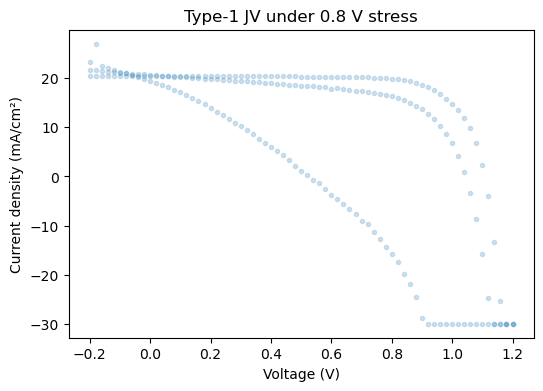

In [16]:
import matplotlib.pyplot as plt

sample = type1_df[type1_df["StressVoltage"] == 0.8]

plt.figure(figsize=(6,4))
plt.plot(sample["MeasuredVoltage"], sample["MeasuredCurrent"], ".", alpha=0.2)
plt.xlabel("Voltage (V)")
plt.ylabel("Current density (mA/cm²)")
plt.title("Type‑1 JV under 0.8 V stress")
plt.show()

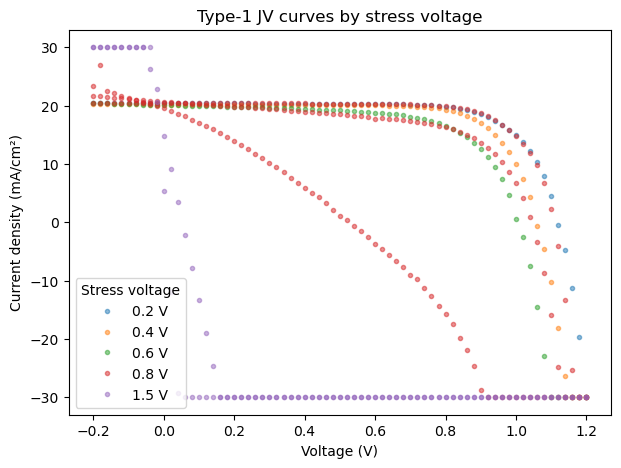

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

for v, g in type1_df.groupby("StressVoltage"):
    plt.plot(
        g["MeasuredVoltage"], g["MeasuredCurrent"],
        ".", label=f"{v} V", alpha=0.5
    )

plt.xlabel("Voltage (V)")
plt.ylabel("Current density (mA/cm²)")
plt.title("Type‑1 JV curves by stress voltage")
plt.legend(title="Stress voltage")
plt.grid(False)
plt.show()

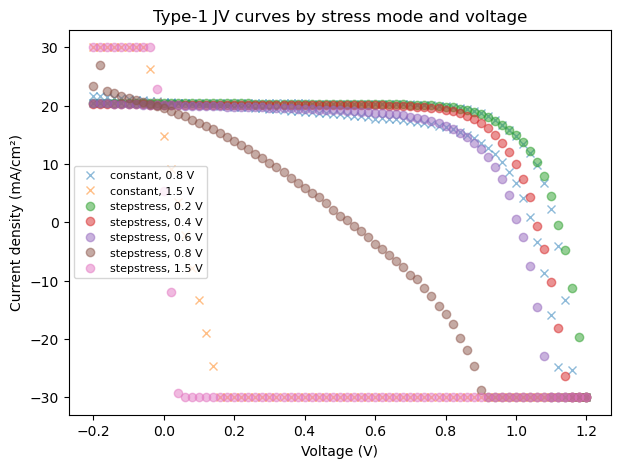

In [22]:
import matplotlib.pyplot as plt

markers = {"stepstress": "o", "constant": "x"}

plt.figure(figsize=(7,5))

for (mode, v), g in type1_df.groupby(["StressMode", "StressVoltage"]):
    plt.plot(
        g["MeasuredVoltage"], g["MeasuredCurrent"],
        marker=markers.get(mode, "."),
        linestyle="None",
        label=f"{mode}, {v} V",
        alpha=0.5
    )

plt.xlabel("Voltage (V)")
plt.ylabel("Current density (mA/cm²)")
plt.title("Type‑1 JV curves by stress mode and voltage")
plt.legend(fontsize=8)
plt.grid(False)
plt.show()

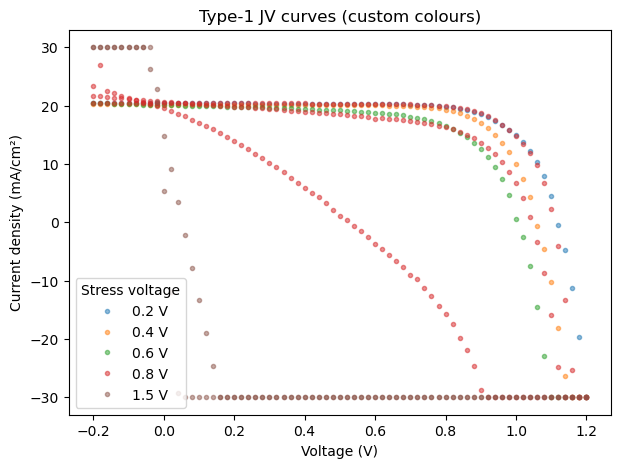

In [21]:
import matplotlib.pyplot as plt

colors = {
    0.2: "tab:blue",
    0.4: "tab:orange",
    0.6: "tab:green",
    0.8: "tab:red",
    1.0: "tab:purple",
    1.5: "tab:brown"
}

plt.figure(figsize=(7,5))

for v, g in type1_df.groupby("StressVoltage"):
    plt.plot(
        g["MeasuredVoltage"], g["MeasuredCurrent"],
        ".", color=colors.get(v, "black"),
        label=f"{v} V", alpha=0.5
    )

plt.xlabel("Voltage (V)")
plt.ylabel("Current density (mA/cm²)")
plt.title("Type‑1 JV curves (custom colours)")
plt.legend(title="Stress voltage")
plt.grid(False)
plt.show()

In [23]:
import os

PLOT_DIR = "../results/plots"
os.makedirs(PLOT_DIR, exist_ok=True)

print("Plots will be saved to:", PLOT_DIR)

Plots will be saved to: ../results/plots


In [24]:
def save_plot(fig, name):
    png_path = os.path.join(PLOT_DIR, f"{name}.png")
    pdf_path = os.path.join(PLOT_DIR, f"{name}.pdf")
    
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")

Saved: ../results/plots\type1_jv_by_stress_voltage.png
Saved: ../results/plots\type1_jv_by_stress_voltage.pdf


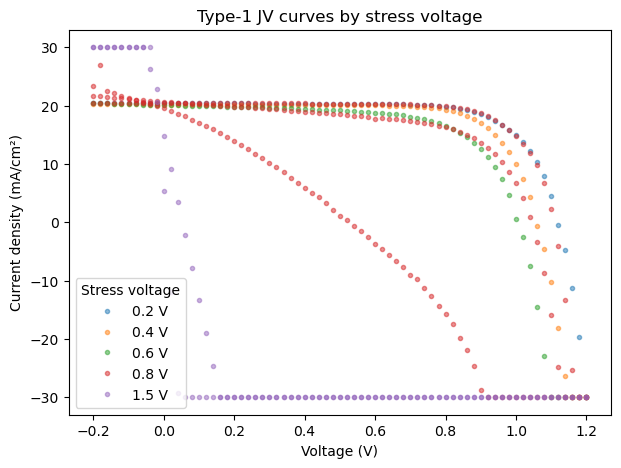

In [26]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(7,5))

for v, g in type1_df.groupby("StressVoltage"):
    plt.plot(
        g["MeasuredVoltage"], g["MeasuredCurrent"],
        ".", alpha=0.5, label=f"{v} V"
    )

plt.xlabel("Voltage (V)")
plt.ylabel("Current density (mA/cm²)")
plt.title("Type‑1 JV curves by stress voltage")
plt.legend(title="Stress voltage")
plt.grid(False)

save_plot(fig, "type1_jv_by_stress_voltage")
plt.show()

Saved: ../results/plots\type1_jv_by_mode_and_voltage.png
Saved: ../results/plots\type1_jv_by_mode_and_voltage.pdf


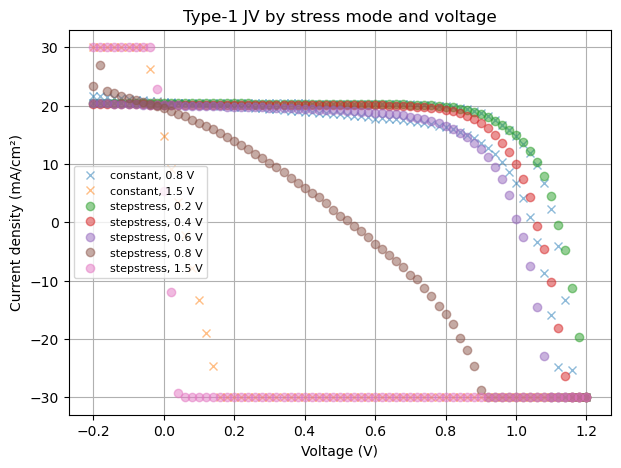

In [27]:
fig = plt.figure(figsize=(7,5))

markers = {"stepstress": "o", "constant": "x"}

for (mode, v), g in type1_df.groupby(["StressMode", "StressVoltage"]):
    plt.plot(
        g["MeasuredVoltage"], g["MeasuredCurrent"],
        linestyle="None",
        marker=markers.get(mode, "."),
        alpha=0.5,
        label=f"{mode}, {v} V"
    )

plt.xlabel("Voltage (V)")
plt.ylabel("Current density (mA/cm²)")
plt.title("Type‑1 JV by stress mode and voltage")
plt.legend(fontsize=8)
plt.grid(True)

save_plot(fig, "type1_jv_by_mode_and_voltage")
plt.show()


Saved: ../results/plots\type1_leakage_vs_stress_voltage.png
Saved: ../results/plots\type1_leakage_vs_stress_voltage.pdf


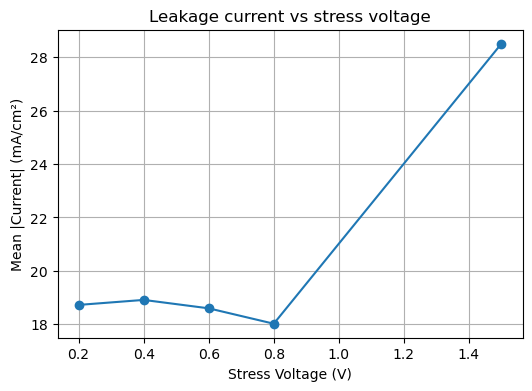

In [28]:
import numpy as np

avg_current = type1_df.groupby("StressVoltage")["AbsCurrent"].mean().reset_index()

fig = plt.figure(figsize=(6,4))
plt.plot(avg_current["StressVoltage"], avg_current["AbsCurrent"], "-o")
plt.xlabel("Stress Voltage (V)")
plt.ylabel("Mean |Current| (mA/cm²)")
plt.title("Leakage current vs stress voltage")
plt.grid(True)

save_plot(fig, "type1_leakage_vs_stress_voltage")
plt.show()


In [29]:
features = (
    type1_df.groupby(["StressMode","StressVoltage","StressDuration_s"])
    .agg(
        Leakage_at_1V = ("MeasuredCurrent", lambda x: x.iloc[(type1_df["MeasuredVoltage"]+1).abs().idxmin()]),
        MaxAbsCurrent = ("AbsCurrent", "max"),
        MeanAbsCurrent = ("AbsCurrent", "mean"),
        StdCurrent = ("MeasuredCurrent", "std"),
    )
    .reset_index()
)

features.to_csv("../results/perovai_type1_features_week08.csv", index=False)

In [31]:
{
  "MeasuredVoltage": "V",
  "MeasuredCurrent": "mA/cm^2",
  "StressVoltage": "V",
  "StressDuration_s": "seconds"
}

{'MeasuredVoltage': 'V',
 'MeasuredCurrent': 'mA/cm^2',
 'StressVoltage': 'V',
 'StressDuration_s': 'seconds'}